# Human Eye Disease Prediction - Model Prediction
**Dataset:** Labeled Optical Coherence Tomography (OCT) - Kaggle  
**Model:** MobileNetV3Large (Transfer Learning)  
**Classes:** CNV, DME, DRUSEN, NORMAL  
**Environment:** TensorFlow-CPU 2.21.0 | Python 3.12 | Windows

## Imports

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Configuration

In [2]:
# ── paths ──────────────────────────────────────────────────────────────────
MODEL_PATH = r'C:\Users\aryap\Downloads\oct dataset\Eye Disease Prediction\Best_Model.keras'
TEST_DIR   = r'C:\Users\aryap\Downloads\oct dataset\Eye Disease Prediction\test'

# ── model settings (must match training) ───────────────────────────────────
IMAGE_SIZE  = (224, 224)
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']   # alphabetical — same order Keras used

## 2. Load the Trained Model

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
print('Model loaded successfully!')
model.summary()

Model loaded successfully!


Model: "EyeDisease_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,689,070 (36.96 MB)

 Trainable params: 3,220,916 (12.29 MB)

 Non-trainable params: 26,320 (102.81 KB)

 Optimizer params: 6,441,834 (24.57 MB)

## 3. Helper - Predict a Single Image
This function takes any image path, preprocesses it exactly the way training did, and returns the predicted class + confidence scores.

In [4]:
def predict_image(img_path, model, class_names, image_size=(224, 224)):
    """
    Load an image, preprocess it, run inference, and return results.

    Parameters
    ----------
    img_path   : str   — full path to the image file
    model      : keras model
    class_names: list  — ordered list of class labels
    image_size : tuple — must match training (224, 224)

    Returns
    -------
    predicted_class : str   — e.g. 'DME'
    confidence      : float — e.g. 0.91
    all_probs       : dict  — {class: probability} for all classes
    """
    # Load and resize
    img = tf.keras.utils.load_img(img_path, target_size=image_size)

    # Convert to array → shape (224, 224, 3)
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension → shape (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Apply MobileNetV3 preprocessing (scales pixels to [-1, 1])
    img_array = preprocess_input(img_array)

    # Run prediction
    preds = model.predict(img_array, verbose=0)   # shape (1, 4)

    # Get the class with highest probability
    result_index    = np.argmax(preds[0])
    predicted_class = class_names[result_index]
    confidence      = float(preds[0][result_index])

    # Build a neat dict of all probabilities
    all_probs = {cls: round(float(prob), 4)
                 for cls, prob in zip(class_names, preds[0])}

    return predicted_class, confidence, all_probs

print('predict_image() function defined.')

predict_image() function defined.


## 4. Predict a Single Image

In [ ]:
img_path = os.path.join(TEST_DIR, 'DRUSEN', 'DRUSEN-1112835-7.jpeg')

# ── run prediction ──────────────────────────────────────────────────────────
predicted_class, confidence, all_probs = predict_image(img_path, model, CLASS_NAMES)

print(f'Image       : {os.path.basename(img_path)}')
print(f'Prediction  : {predicted_class}')
print(f'Confidence  : {confidence * 100:.2f}%')
print(f'All scores  : {all_probs}')

Image       : DRUSEN-1112835-7.jpeg
Prediction  : DRUSEN
Confidence  : 61.18%
All scores  : {'CNV': 0.3878, 'DME': 0.0001, 'DRUSEN': 0.6118, 'NORMAL': 0.0002}


## 5. Visualise — Image + Confidence Bar Chart

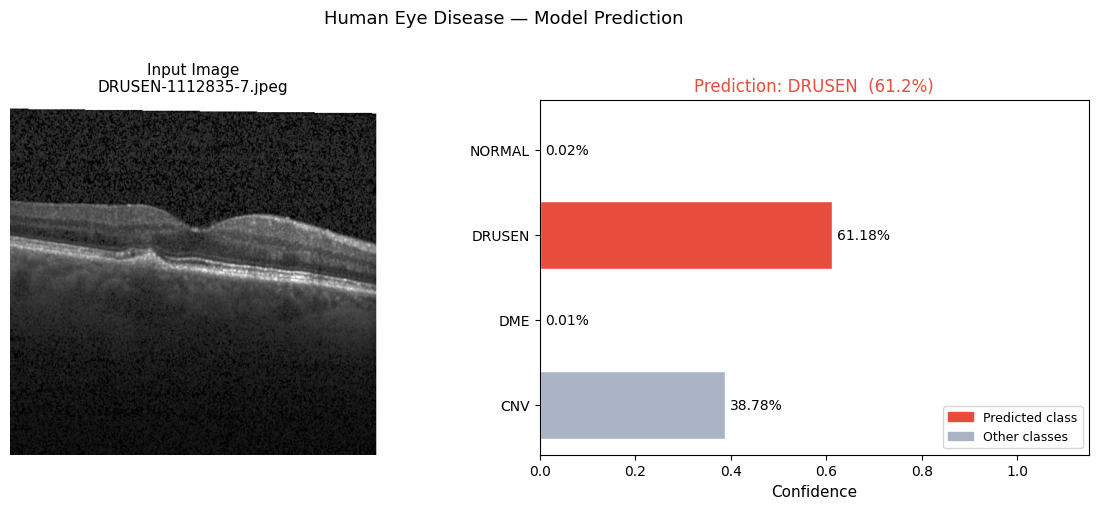

Saved: single_prediction.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── left: the OCT image ─────────────────────────────────────────────────────
img_display = tf.keras.utils.load_img(img_path)
axes[0].imshow(img_display)
axes[0].set_title(f'Input Image\n{os.path.basename(img_path)}', fontsize=11)
axes[0].axis('off')

# ── right: probability bar chart ────────────────────────────────────────────
colors  = ['#e74c3c' if cls == predicted_class else '#aab4c4' for cls in CLASS_NAMES]
bars    = axes[1].barh(CLASS_NAMES, list(all_probs.values()), color=colors, edgecolor='white')

# Add percentage labels on each bar
for bar, prob in zip(bars, all_probs.values()):
    axes[1].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{prob * 100:.2f}%',
        va='center', fontsize=10
    )

axes[1].set_xlim(0, 1.15)
axes[1].set_xlabel('Confidence', fontsize=11)
axes[1].set_title(f'Prediction: {predicted_class}  ({confidence*100:.1f}%)', fontsize=12, color='#e74c3c')

red_patch  = mpatches.Patch(color='#e74c3c', label='Predicted class')
gray_patch = mpatches.Patch(color='#aab4c4', label='Other classes')
axes[1].legend(handles=[red_patch, gray_patch], loc='lower right', fontsize=9)

plt.suptitle('Human Eye Disease — Model Prediction', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('single_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: single_prediction.png')

## 6. Predict Multiple Images at Once
Tests one random image from each class so you can see how the model performs across all four diseases.

In [7]:
import random

# Pick one random image per class from the test folder
sample_images = []
for cls in CLASS_NAMES:
    cls_folder = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_folder):
        files = [f for f in os.listdir(cls_folder)
                 if f.lower().endswith(('.jpeg', '.jpg', '.png'))]
        if files:
            chosen = random.choice(files)
            sample_images.append({
                'path'      : os.path.join(cls_folder, chosen),
                'true_label': cls
            })

print(f'Sampled {len(sample_images)} images (one per class)')

Sampled 4 images (one per class)


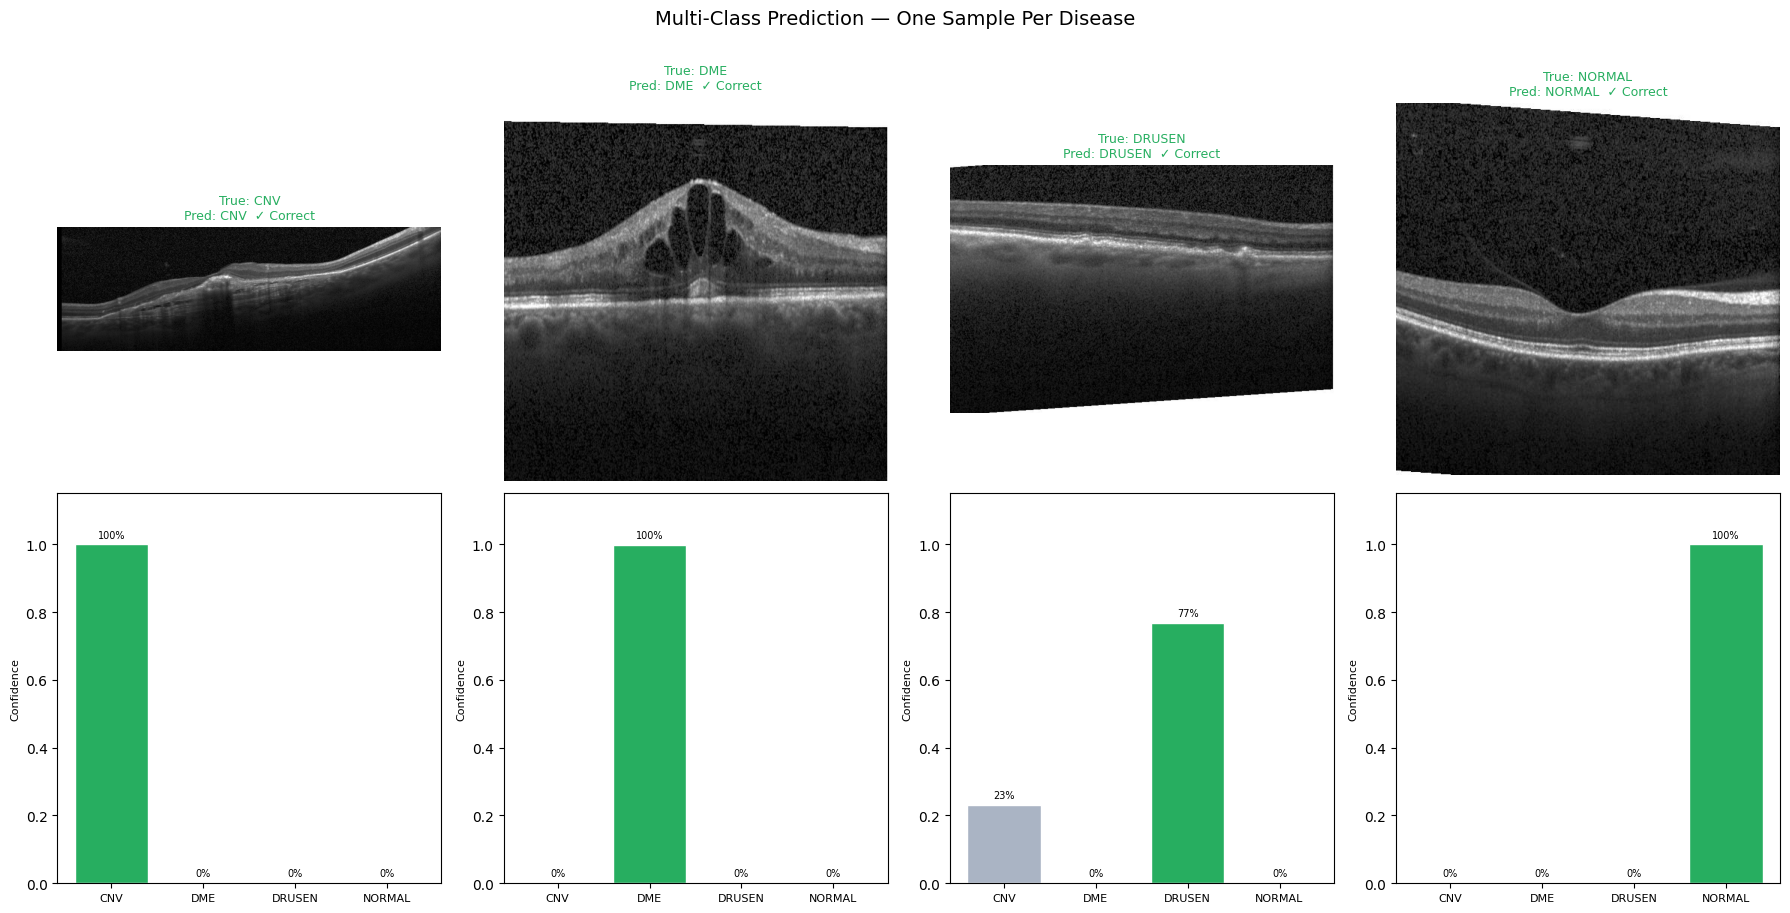

Saved: multi_prediction.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, sample in enumerate(sample_images):
    pred_class, conf, probs = predict_image(sample['path'], model, CLASS_NAMES)
    true_label = sample['true_label']
    is_correct = (pred_class == true_label)

    # Top row: OCT image
    img_display = tf.keras.utils.load_img(sample['path'])
    axes[0][i].imshow(img_display)
    border_color = '#27ae60' if is_correct else '#e74c3c'
    for spine in axes[0][i].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    status = '✓ Correct' if is_correct else '✗ Wrong'
    axes[0][i].set_title(
        f'True: {true_label}\nPred: {pred_class}  {status}',
        fontsize=9,
        color=border_color
    )
    axes[0][i].axis('off')

    # Bottom row: probability bar chart
    colors = ['#27ae60' if cls == pred_class else '#aab4c4' for cls in CLASS_NAMES]
    axes[1][i].bar(CLASS_NAMES, list(probs.values()), color=colors, edgecolor='white')
    axes[1][i].set_ylim(0, 1.15)
    axes[1][i].set_ylabel('Confidence', fontsize=8)
    axes[1][i].tick_params(axis='x', labelsize=8)
    for j, (cls, prob) in enumerate(probs.items()):
        axes[1][i].text(j, prob + 0.02, f'{prob*100:.0f}%',
                        ha='center', fontsize=7)

plt.suptitle('Multi-Class Prediction — One Sample Per Disease', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('multi_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: multi_prediction.png')

## 7. Recommendation Based on Prediction
Shows the medical recommendation for the predicted disease.

In [9]:
# ── Disease recommendations ─────────────────────────────────────────────────
recommendations = {
    'CNV': """
FOR CNV (Choroidal Neovascularization)
=======================================
• Immediate Referral: Seek prompt evaluation by a retinal specialist.
  CNV is often associated with age-related macular degeneration (AMD)
  and can lead to significant vision loss if untreated.

• Treatment Options:
  - Anti-VEGF Therapy (Ranibizumab or Aflibercept injections)
  - Photodynamic Therapy (PDT) alongside anti-VEGF in some cases
  - Laser Treatment in certain situations

• Lifestyle & Monitoring:
  - Diet rich in leafy greens, omega-3 fatty acids, antioxidants
  - Consider AREDS2 supplements for AMD patients
  - Repeat OCT scans every 1–3 months

• Next Steps:
  - Schedule immediate follow-up with a retina specialist
  - Begin anti-VEGF treatment as recommended
""",
    'DME': """
FOR DME (Diabetic Macular Edema)
=================================
• Endocrinology Consultation: Close coordination with an endocrinologist
  is essential to manage systemic diabetes.

• Treatment Options:
  - Anti-VEGF Injections (first-line treatment)
  - Corticosteroid Implants (if anti-VEGF is less effective)
  - Focal/Grid Laser Photocoagulation for non-central-involved DME

• Blood Sugar & Blood Pressure Control:
  - Keep HbA1c below 7% to slow progression
  - Maintain blood pressure below 140/80 mmHg

• Monitoring:
  - OCT scans every 3–6 months
  - Tight control of diabetes and blood pressure

• Next Steps:
  - Visit retina specialist and endocrinologist
  - Begin or continue anti-VEGF treatment
""",
    'DRUSEN': """
FOR DRUSEN (Early AMD)
=======================
• Dietary Changes:
  - Foods rich in vitamins C, E, zinc, beta-carotene (spinach, kale, fish)
  - AREDS2 supplement formulation recommended for moderate to high-risk patients

• Lifestyle Modifications:
  - Quit smoking — greatly increases AMD progression risk
  - Wear UV-protective sunglasses

• Monitoring:
  - OCT scans every 6–12 months to track drusen changes
  - Use Amsler grid at home to self-monitor vision changes

• Next Steps:
  - Discuss AREDS2 supplements with your healthcare provider
  - Schedule routine OCT scans
""",
    'NORMAL': """
FOR NORMAL RETINA
==================
• Your OCT scan shows a normal retina. No immediate treatment needed.

• Eye Health Maintenance:
  - Balanced diet rich in dark leafy greens, omega-3 fatty acids, antioxidants
  - Wear UV-protective sunglasses

• Next Steps:
  - Routine eye exams every 1–2 years (or as recommended by your ophthalmologist)
  - Manage conditions like diabetes or hypertension that could affect retinal health
"""
}

print('Recommendations loaded for all 4 classes.')

Recommendations loaded for all 4 classes.


In [ ]:
# ── Run prediction and show recommendation ──────────────────────────────────
img_path = os.path.join(TEST_DIR, 'CNV', os.listdir(os.path.join(TEST_DIR, 'CNV'))[0])

predicted_class, confidence, all_probs = predict_image(img_path, model, CLASS_NAMES)

print('=' * 50)
print(f'  IMAGE     : {os.path.basename(img_path)}')
print(f'  PREDICTED : {predicted_class}')
print(f'  CONFIDENCE: {confidence * 100:.2f}%')
print('=' * 50)
print()
print(recommendations[predicted_class])

  IMAGE     : CNV-1016042-122.jpeg
  PREDICTED : CNV
  CONFIDENCE: 99.99%


FOR CNV (Choroidal Neovascularization)
• Immediate Referral: Seek prompt evaluation by a retinal specialist.
  CNV is often associated with age-related macular degeneration (AMD)
  and can lead to significant vision loss if untreated.

• Treatment Options:
  - Anti-VEGF Therapy (Ranibizumab or Aflibercept injections)
  - Photodynamic Therapy (PDT) alongside anti-VEGF in some cases
  - Laser Treatment in certain situations

• Lifestyle & Monitoring:
  - Diet rich in leafy greens, omega-3 fatty acids, antioxidants
  - Consider AREDS2 supplements for AMD patients
  - Repeat OCT scans every 1–3 months

• Next Steps:
  - Schedule immediate follow-up with a retina specialist
  - Begin anti-VEGF treatment as recommended



## 8. Predict Your Own Custom Image
Put the full path to any OCT image here and run this cell.

In [ ]:
my_image = r'C:\path\to\your\image.jpeg'   

if os.path.exists(my_image):
    predicted_class, confidence, all_probs = predict_image(my_image, model, CLASS_NAMES)

    # Show image + result
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    img_display = tf.keras.utils.load_img(my_image)
    axes[0].imshow(img_display)
    axes[0].set_title(f'Your Image\n{os.path.basename(my_image)}', fontsize=11)
    axes[0].axis('off')

    colors = ['#e74c3c' if cls == predicted_class else '#aab4c4' for cls in CLASS_NAMES]
    bars   = axes[1].barh(CLASS_NAMES, list(all_probs.values()), color=colors, edgecolor='white')
    for bar, prob in zip(bars, all_probs.values()):
        axes[1].text(bar.get_width() + 0.01,
                     bar.get_y() + bar.get_height() / 2,
                     f'{prob * 100:.2f}%', va='center', fontsize=10)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xlabel('Confidence', fontsize=11)
    axes[1].set_title(f'Prediction: {predicted_class}  ({confidence*100:.1f}%)',
                      fontsize=12, color='#e74c3c')
    plt.tight_layout()
    plt.show()

    print(f'\nPredicted Class : {predicted_class}')
    print(f'Confidence      : {confidence * 100:.2f}%')
    print()
    print(recommendations[predicted_class])
else:
    print(f'File not found: {my_image}')
    print('Please update the my_image path above and run again.')

File not found: C:\path\to\your\image.jpeg
Please update the my_image path above and run again.
